<a href="https://colab.research.google.com/github/bala-baskar/aiml_tech_courses/blob/main/pytorch_ultimate/mastering_pytorch_nb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regression model using Pytorch

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

In [2]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

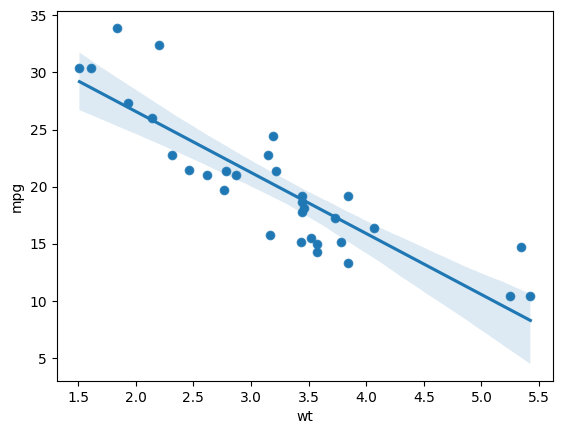

In [3]:
sns.scatterplot(x='wt',y='mpg',data=cars)
sns.regplot(x='wt',y='mpg',data=cars)

In [4]:
# Convert data into tensor
X_list = cars.wt.values
y_list = cars.mpg.values

X = torch.tensor(X_list)
y = torch.tensor(y_list)

In [5]:
# Training
w = torch.rand(1,requires_grad=True,dtype=torch.float32)
b = torch.rand(1,requires_grad=True,dtype=torch.float32)

In [6]:
w,b

(tensor([0.1832], requires_grad=True), tensor([0.6628], requires_grad=True))

In [7]:
num_epochs = 1000
learning_rate = 0.001

for epoch in range(num_epochs):
  for i in range(len(X)):
    # forward pass
    y_pred = X[i] * w + b
    # calculate loss
    loss_tensor = torch.pow(y_pred - y[i],2)

    #backward pass
    loss_tensor.backward()

    #extract losses
    loss_value = loss_tensor.item()

    with torch.no_grad():
      w -= w.grad * learning_rate
      b -= b.grad * learning_rate
      w.grad.zero_()
      b.grad.zero_()
  print(loss_value)

159.22581481933594
80.94198608398438
53.88584899902344
43.20981979370117
38.54020309448242
36.295196533203125
35.085716247558594
34.33236312866211
33.78400421142578
33.32952117919922
32.919334411621094
32.53118133544922
32.1551513671875
31.78660774230957
31.42361068725586
31.065153121948242
30.710834503173828
30.360397338867188
30.013736724853516
29.6707706451416
29.331459045410156
28.99576187133789
28.66362190246582
28.335018157958984
28.009885787963867
27.688234329223633
27.369976043701172
27.055105209350586
26.743576049804688
26.435380935668945
26.13045310974121
25.828767776489258
25.530317306518555
25.23501968383789
24.942907333374023
24.65389633178711
24.367963790893555
24.085084915161133
23.805233001708984
23.52838706970215
23.25450325012207
22.983539581298828
22.7154541015625
22.450279235839844
22.18790054321289
21.928403854370117
21.671659469604492
21.417661666870117
21.16640853881836
20.9178409576416
20.67195701599121
20.42873191833496
20.188112258911133
19.95009422302246
19.7

In [8]:
print(w,b)

tensor([-5.2307], requires_grad=True) tensor([36.8098], requires_grad=True)


In [9]:
prediction = X * w + b
prediction

tensor([23.1054, 21.7716, 24.6746, 19.9932, 18.8163, 18.7117, 18.1363, 20.1240,
        20.3332, 18.8163, 18.8163, 15.5210, 17.2994, 17.0379,  9.3488,  8.4386,
         8.8519, 25.3023, 28.3623, 27.2115, 23.9162, 18.3978, 18.8424, 16.7240,
        16.6979, 26.6884, 25.6162, 28.8958, 20.2286, 22.3208, 18.1363, 22.2685],
       dtype=torch.float64, grad_fn=<AddBackward0>)

In [10]:
y

tensor([21.0000, 21.0000, 22.8000, 21.4000, 18.7000, 18.1000, 14.3000, 24.4000,
        22.8000, 19.2000, 17.8000, 16.4000, 17.3000, 15.2000, 10.4000, 10.4000,
        14.7000, 32.4000, 30.4000, 33.9000, 21.5000, 15.5000, 15.2000, 13.3000,
        19.2000, 27.3000, 26.0000, 30.4000, 15.8000, 19.7000, 15.0000, 21.4000],
       dtype=torch.float64)

<Axes: xlabel='None'>

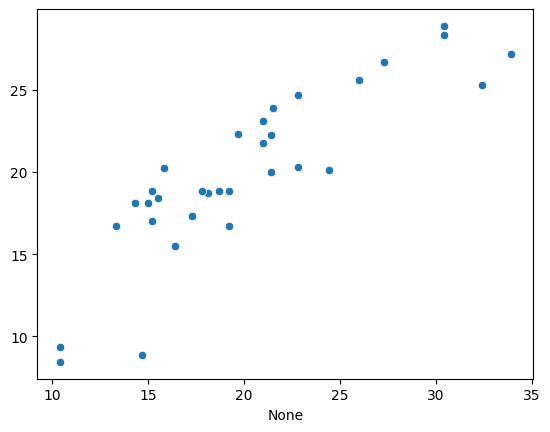

In [11]:
sns.scatterplot(x=y,y=prediction.detach().numpy())

In [12]:
!pip install -qU torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.8 MB/s eta 0:00:00


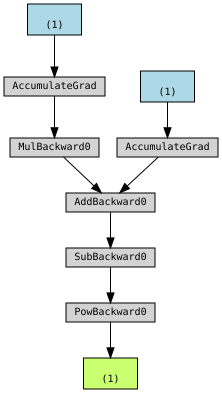

In [13]:
import os
from torchviz import make_dot
make_dot(loss_tensor)

## Going modular

In [19]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

In [20]:
class LinearRegressionTorch(nn.Module):
  def __init__(self,input_size,output_size):
    super().__init__()
    self.linear = nn.Linear(input_size,output_size)

  def forward(self,x):
    return self.linear(x)

In [25]:
input_dim = 1
output_dim = 1
model = LinearRegressionTorch(input_dim,output_dim)
model

LinearRegressionTorch(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [26]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.4225]])),
             ('linear.bias', tensor([-0.5362]))])

In [27]:
# Loss function
loss_fun = nn.MSELoss()
alpha = 0.02
optimizer = torch.optim.SGD(model.parameters(),lr=alpha)

In [28]:
# Train the model
losses, slope, bias = [], [], []

NUM_EPOCHS = 1000
BATCH_SIZE = 2
for epoch in range(NUM_EPOCHS):
  for i in range(0,X.shape[0],BATCH_SIZE):

    # set gradients to zero
    optimizer.zero_grad()

    # forward pass
    y_pred = model(X[i:i+BATCH_SIZE])

    # compile loss
    loss = loss_fun(y_pred, y_true[i:i+BATCH_SIZE])
    loss.backward()

    #update weights
    optimizer.step()

  #get parameters
  for name, param in model.named_parameters():
    # print(name, param)
    if param.requires_grad:
      if name == "linear.weight":
        slope.append(param.item())
      if name == "linear.bias":
        bias.append(param.item())

  # store loss
  losses.append(loss.item())

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss {round(loss.item(),4)}")

Epoch 0, Loss 36.5577
Epoch 100, Loss 1.5709
Epoch 200, Loss 1.4116
Epoch 300, Loss 1.4094
Epoch 400, Loss 1.4094
Epoch 500, Loss 1.4094
Epoch 600, Loss 1.4094
Epoch 700, Loss 1.4094
Epoch 800, Loss 1.4094
Epoch 900, Loss 1.4094


<Axes: >

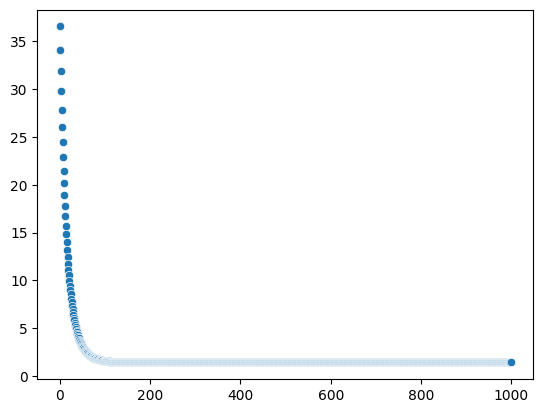

In [29]:
sns.scatterplot(x=range(NUM_EPOCHS),y=losses)

<Axes: >

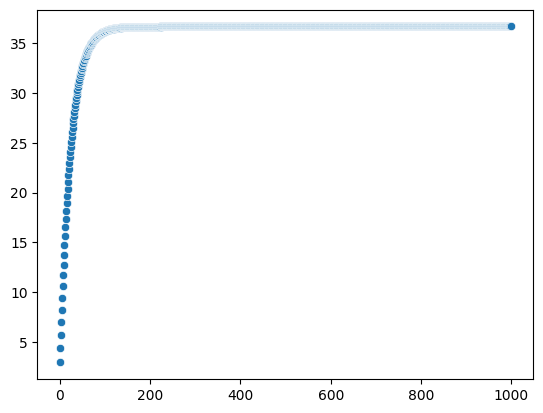

In [30]:
sns.scatterplot(x=range(NUM_EPOCHS),y=bias)

<Axes: >

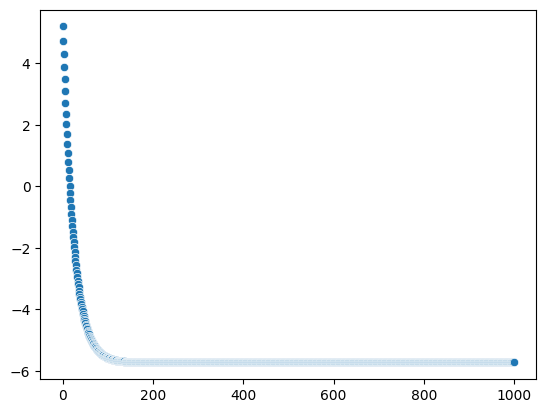

In [31]:
sns.scatterplot(x=range(NUM_EPOCHS),y=slope)

In [32]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-5.7225]])),
             ('linear.bias', tensor([36.6935]))])

<Axes: >

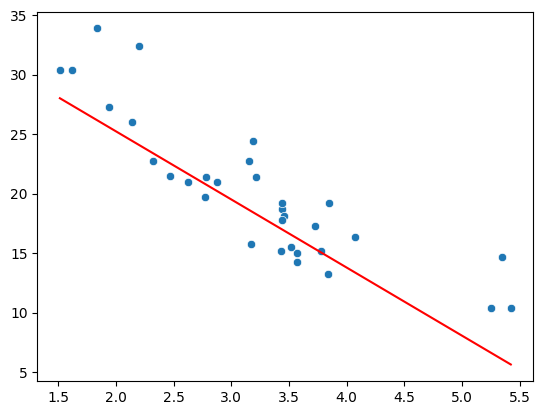

In [33]:
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')

### DataSets and DataLoaders

In [34]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

In [35]:
from torch.utils.data import Dataset, DataLoader
class LinearRegressionDataset(Dataset):
  def __init__(self,X,y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [53]:
train_data = DataLoader(dataset=LinearRegressionDataset(X_np,y_np),batch_size=2)

In [54]:
class LinearRegressionTorch(nn.Module):
  def __init__(self,input_size,output_size):
    super().__init__()
    self.linear = nn.Linear(input_size,output_size)

  def forward(self,x):
    return self.linear(x)

In [55]:
input_dim = 1
output_dim = 1
model = LinearRegressionTorch(input_dim,output_dim)
model

LinearRegressionTorch(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [56]:
# Loss function
loss_fun = nn.MSELoss()
alpha = 0.02
optimizer = torch.optim.SGD(model.parameters(),lr=alpha)

In [57]:
for i, data in enumerate(train_data):
  print(f"{i}th batch")
  print(f"X = {data[0]}, y = {data[1]}")

0th batch
X = tensor([[2.6200],
        [2.8750]]), y = tensor([[21.],
        [21.]])
1th batch
X = tensor([[2.3200],
        [3.2150]]), y = tensor([[22.8000],
        [21.4000]])
2th batch
X = tensor([[3.4400],
        [3.4600]]), y = tensor([[18.7000],
        [18.1000]])
3th batch
X = tensor([[3.5700],
        [3.1900]]), y = tensor([[14.3000],
        [24.4000]])
4th batch
X = tensor([[3.1500],
        [3.4400]]), y = tensor([[22.8000],
        [19.2000]])
5th batch
X = tensor([[3.4400],
        [4.0700]]), y = tensor([[17.8000],
        [16.4000]])
6th batch
X = tensor([[3.7300],
        [3.7800]]), y = tensor([[17.3000],
        [15.2000]])
7th batch
X = tensor([[5.2500],
        [5.4240]]), y = tensor([[10.4000],
        [10.4000]])
8th batch
X = tensor([[5.3450],
        [2.2000]]), y = tensor([[14.7000],
        [32.4000]])
9th batch
X = tensor([[1.6150],
        [1.8350]]), y = tensor([[30.4000],
        [33.9000]])
10th batch
X = tensor([[2.4650],
        [3.5200]]), y = t

In [58]:
# Train the model
losses, slope, bias = [], [], []

NUM_EPOCHS = 1000
BATCH_SIZE = 2
for epoch in range(NUM_EPOCHS):
  for i, (X,y) in enumerate(train_data):

    # set gradients to zero
    optimizer.zero_grad()

    # forward pass
    y_pred = model(X)

    # compile loss
    loss = loss_fun(y_pred, y)
    loss.backward()

    #update weights
    optimizer.step()

  #get parameters
  for name, param in model.named_parameters():
    # print(name, param)
    if param.requires_grad:
      if name == "linear.weight":
        slope.append(param.item())
      if name == "linear.bias":
        bias.append(param.item())

  # store loss
  losses.append(loss.item())

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss {round(loss.item(),4)}")

Epoch 0, Loss 36.0832
Epoch 100, Loss 1.5696
Epoch 200, Loss 1.4116
Epoch 300, Loss 1.4094
Epoch 400, Loss 1.4094
Epoch 500, Loss 1.4094
Epoch 600, Loss 1.4094
Epoch 700, Loss 1.4094
Epoch 800, Loss 1.4094
Epoch 900, Loss 1.4094


In [59]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-5.7225]])),
             ('linear.bias', tensor([36.6935]))])

### Model saving and loading

In [64]:
PATH = "/content/sample_data/model_state_dict.pth"
torch.save(model.state_dict(), PATH)

In [65]:
model_2 = LinearRegressionTorch(input_size=input_dim,output_size=output_dim)
model_2.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [66]:
model_2.state_dict()

OrderedDict([('linear.weight', tensor([[-5.7225]])),
             ('linear.bias', tensor([36.6935]))])

### Hyper parameter tuning

1. Network topology - Number of nodes, layer types, activation functions
2. Network objects - loss function, optimizer
3. Model training - Learning rate, batch size, number of epochs


##### Batch size

||GPU utilisation|iterations|Training-stability|
|---|---|---|---|
|Small batch size| DOWN (bad) | UP (bad) | UP (good) |
|Large batch size| UP (good) | DOWN (good) | DOWN (bad) |


##### Number of EPOCHS

||Training time|inference time|Model performance|Stability|
|---|---|---|---|---|
|Low| DOWN (good) | NA | DOWN (bad) | UP (good) |
|High| UP (bad) | NA | UP (good) | DOWN (bad) |

##### Hidden layers

||Ability to learn complex patterns|Training time|Inference time|Risk of overfitting|
|---|---|---|---|---|
|Few| DOWN (bad) | DOWN (good) | DOWN (good) | DOWN (good) |
|Many| UP (good) | UP (bad) | UP (bad) | UP (bad) |

##### Number of nodes within layer

||Ability to learn complex patterns|Training time|Inference time|Risk of overfitting|
|---|---|---|---|---|
|Few| DOWN (bad) | DOWN (good) | DOWN (good) | DOWN (good) |
|Many| UP (good) | UP (bad) | UP (bad) | UP (bad) |

### Multi class classification model

In [71]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import os
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [68]:
iris = load_iris()
X = iris['data']
y = iris['target']

In [70]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=123)

In [74]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [82]:
from torch.utils.data import Dataset, DataLoader
class LoadIrisDataset(Dataset):
  def __init__(self,X_train,y_train):
    self.X = torch.from_numpy(X_train)
    self.y = torch.from_numpy(y_train)
    self.y = self.y.type(torch.LongTensor)

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [83]:
iris_data = LoadIrisDataset(X_train,y_train)
train_loader = DataLoader(dataset=iris_data,batch_size=32,shuffle=True)

In [84]:
class MultiClassNeuralNetwork(nn.Module):
  def __init__(self,INPUT_SIZE, NUM_CLASSES, HIDDEN_SIZE):
    super().__init__()
    self.lin1 = nn.Linear(INPUT_SIZE,HIDDEN_SIZE)
    self.lin2 = nn.Linear(HIDDEN_SIZE,NUM_CLASSES)
    self.log_softmax = nn.LogSoftmax(dim=1)

  def forward(self,x):
    x = self.lin1(x)
    x = torch.sigmoid(x)
    x = self.lin2(x)
    x = torch.sigmoid(x)
    x = self.log_softmax(x)
    return x

In [112]:
INPUT_SIZE = iris_data.X.shape[1]
HIDDEN_SIZE = 6
NUM_CLASSES = len(iris_data.y.unique())
alpha = 0.1
print(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES)

4 6 3


In [113]:
model = MultiClassNeuralNetwork(INPUT_SIZE=INPUT_SIZE,
                                HIDDEN_SIZE=HIDDEN_SIZE,
                                NUM_CLASSES=NUM_CLASSES)
model.state_dict()

OrderedDict([('lin1.weight',
              tensor([[ 0.4240, -0.4180,  0.3113, -0.1071],
                      [ 0.1803,  0.1424,  0.2737, -0.3119],
                      [ 0.4878, -0.4474, -0.1282, -0.3686],
                      [-0.1161, -0.2235,  0.0439,  0.1229],
                      [-0.3226, -0.2378, -0.1268, -0.3335],
                      [-0.1227, -0.0168, -0.0352,  0.4200]])),
             ('lin1.bias',
              tensor([ 0.4514, -0.1699, -0.1064,  0.2215, -0.2041, -0.3045])),
             ('lin2.weight',
              tensor([[-3.6949e-01,  3.7482e-01,  1.8492e-01,  3.7785e-01, -1.0785e-01,
                        9.2352e-02],
                      [-1.8914e-01,  2.1882e-01,  1.7663e-01,  1.5286e-01, -2.3589e-04,
                       -1.8756e-01],
                      [-1.6099e-01,  3.9038e-01,  1.4575e-02,  1.2130e-01, -1.1984e-01,
                       -6.5839e-02]])),
             ('lin2.bias', tensor([ 0.3649, -0.3620,  0.3175]))])

In [114]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=alpha)

In [115]:
NUM_EPOCHS = 100
losses = []
for epoch in range(NUM_EPOCHS):
  for X,y in train_loader:
    #set the grads to zero
    optimizer.zero_grad()
    #forward pass
    y_pred = model(X)
    # compute loss function
    loss = loss_fn(y_pred, y)
    loss.backward()

    #update weights
    optimizer.step()


  losses.append(float(loss.data.detach().numpy()))

<Axes: >

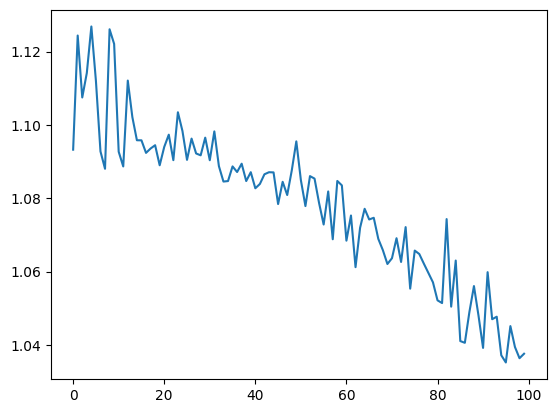

In [116]:
sns.lineplot(x=range(NUM_EPOCHS),y=losses)

In [117]:
# test the model
X_tst_torch = torch.from_numpy(X_test)
with torch.no_grad():
  y_test_log = model(X_tst_torch)
  y_test_pred = torch.max(y_test_log.data, dim=1)

In [118]:
y_test_pred.indices

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])

In [119]:
pd.crosstab(y_test,y_test_pred.indices)

col_0,0,1
row_0,,
0,1,12
1,0,6
2,0,11


### MultiLabel classification

In [131]:
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [132]:
X, y = make_multilabel_classification(n_samples=10000, n_features=10,n_classes=3, n_labels=2)
X_torch = torch.FloatTensor(X)
y_torch = torch.FloatTensor(y)

In [133]:
y

array([[1, 1, 0],
       [0, 0, 0],
       [0, 0, 0],
       ...,
       [0, 0, 0],
       [1, 1, 1],
       [1, 1, 1]])

In [134]:
X_train,X_test, y_train, y_test = train_test_split(X_torch, y_torch, test_size=0.3,random_state=123)

In [137]:
class MultiLabelDataset(Dataset):
  def __init__(self,X,y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [139]:
multi_train_label = MultiLabelDataset(X_train,y_train)
multi_test_label = MultiLabelDataset(X_test,y_test)

In [140]:
train_loader = DataLoader(dataset=multi_train_label,batch_size=32,shuffle=True)
test_loader = DataLoader(dataset=multi_test_label,batch_size=32,shuffle=True)

In [141]:
class MultiLabelNeuralNet(nn.Module):
  def __init__(self,INPUT_SIZE,HIDDEN_SIZE,OUTPUT_SIZE):
    super().__init__()
    self.fc1 = nn.Linear(INPUT_SIZE,HIDDEN_SIZE)
    self.fc2 = nn.Linear(HIDDEN_SIZE,OUTPUT_SIZE)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x

In [143]:
INPUT_SIZE = multi_train_label.X.shape[1]
OUTPUT_SIZE = multi_train_label.y.shape[1]
HIDDEN_SIZE = 10
alpha = 0.01

In [144]:
model = MultiLabelNeuralNet(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
model.state_dict()

OrderedDict([('fc1.weight',
              tensor([[-0.1680, -0.2425, -0.2447, -0.1109, -0.0549, -0.2755, -0.2801,  0.2674,
                       -0.2470,  0.2953],
                      [-0.0811,  0.3105, -0.3120,  0.2559,  0.2336, -0.0280, -0.2583, -0.1260,
                       -0.2749, -0.2806],
                      [ 0.1408,  0.0058, -0.0685, -0.0607,  0.2206, -0.2166,  0.1135,  0.1930,
                        0.2972,  0.2149],
                      [ 0.1725, -0.1251,  0.0744,  0.2977,  0.2670, -0.2070,  0.3126,  0.0616,
                       -0.0632,  0.2147],
                      [-0.1342,  0.0665, -0.2569, -0.2965,  0.1314,  0.0064,  0.0244,  0.1540,
                       -0.1189, -0.2937],
                      [-0.1450,  0.1567, -0.0135, -0.0004, -0.0015,  0.1017,  0.2303,  0.2447,
                        0.0551, -0.3108],
                      [-0.0260, -0.2659,  0.2240,  0.1615, -0.0246,  0.0951, -0.0015,  0.0963,
                        0.0222,  0.0106],
             

In [147]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=alpha)

In [152]:
# Training loop
NUM_EPOCHS = 100
losses = []
for epoch in range(NUM_EPOCHS):
  for i, (X,y) in enumerate(train_loader):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    loss.backward()
    optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item()}")
    losses.append(loss.item())

Epoch 0, Loss: 0.5392174124717712
Epoch 10, Loss: 0.551426887512207
Epoch 20, Loss: 0.5445796847343445
Epoch 30, Loss: 0.5373452305793762
Epoch 40, Loss: 0.5000331997871399
Epoch 50, Loss: 0.5956132411956787
Epoch 60, Loss: 0.5690659284591675
Epoch 70, Loss: 0.5378202199935913
Epoch 80, Loss: 0.6610627770423889
Epoch 90, Loss: 0.5847177505493164


<Axes: >

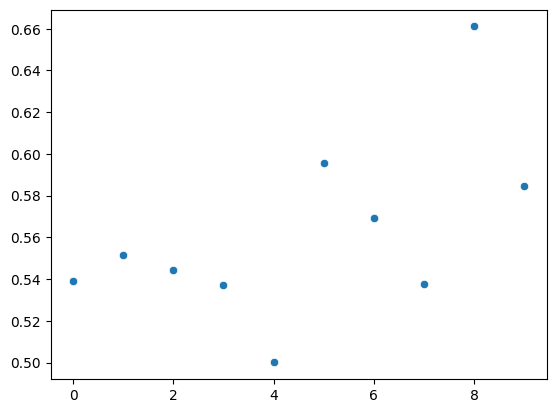

In [153]:
sns.scatterplot(x=range(len(losses)),y=losses)

In [154]:
with torch.no_grad():
  y_test_pred = model(X_test).round()

In [155]:
y_test_pred

tensor([[1., 1., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        ...,
        [1., 0., 1.],
        [0., 1., 1.],
        [0., 1., 1.]])

In [169]:
y_test_str = []
for i in y_test.detach().numpy():
  y_test_str.append(''.join([str(int(x)) for x in i.tolist()]))

In [170]:
y_test_pred_str = []
for i in y_test_pred.detach().numpy():
  y_test_pred_str.append(''.join([str(int(x)) for x in i.tolist()]))

In [171]:
pd.crosstab(y_test_str, y_test_pred_str)

col_0,000,001,010,011,100,101,110,111
row_0,,,,,,,,
000,366,18,8,6,17,24,14,19
001,1,395,0,3,0,1,0,0
010,0,0,200,4,1,0,30,3
011,22,34,17,161,0,22,4,72
100,13,0,0,0,237,14,44,5
101,37,30,0,7,22,256,6,53
110,11,0,33,0,33,4,104,9
111,54,19,22,55,35,130,78,247
